In [ ]:
import pandas as pd
import numpy as np
import warnings
import time
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.ensemble         import RandomForestRegressor
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import TimeSeriesSplit
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

warnings.filterwarnings('ignore')

from pathlib import Path

DATA_PATH = Path('features_weekly.csv')
OUTPUT_DIR = Path('.')

RANDOM_STATE = 42
N_SPLITS = 5
LOG_TARGET = True  # Log-transform target để xử lý skewness

Bài toán : Dự đoán doanh thu tuần kế tiếp theo từng bang (customer_state)
Target   : target_next_revenue  (continuous, highly right-skewed, skew≈5.27)
Data     : 2 600 rows | 27 states × 84 weeks | 43 features

4 mô hình được so sánh:
  - Linear Regression    — Baseline
  - Ridge Regression     — Regularized linear (xử lý multicollinearity giữa các lag)
  - Random Forest        — Ensemble phi tuyến, robust outlier
  - LightGBM             — Gradient Boosting SOTA cho tabular/panel data

In [11]:
print("1. LOADING DATA")

df = pd.read_csv(DATA_PATH)
print(f"   Shape: {df.shape}")

# Encode customer_state thành int (LightGBM/RF dùng được)
df['state_code'] = df['customer_state'].astype('category').cat.codes

# Sắp xếp theo thời gian (quan trọng với TimeSeriesSplit)
df = df.sort_values('year_week').reset_index(drop=True)

1. LOADING DATA
   Shape: (2600, 43)


In [ ]:
print("TARGET VARIABLE: target_next_revenue")
print(df['target_next_revenue'].describe())
print(f"\nSkewness: {df['target_next_revenue'].skew():.3f}")
print(f"Zeros: {(df['target_next_revenue'] == 0).sum()} / {len(df)}")

In [12]:
grp = df.groupby('customer_state')
df['revenue_std_4']   = grp['revenue'].transform(lambda x: x.shift(1).rolling(4, min_periods=2).std()).fillna(0)
df['revenue_momentum'] = (df['revenue_lag_1'] - df['revenue_lag_4']).fillna(0)   # Xu hướng tăng trưởng

In [13]:
# ─── 3. Feature Selection ───────────────────────────────────────────────────
# Loại bỏ: identifier, target, cột gốc bị leak (revenue hiện tại không dùng làm feature trực tiếp
# vì target_next_revenue = shift(-1) của revenue, không bị leak)
EXCLUDE = ['customer_state', 'year_week', 'target_next_revenue',
           # Loại các cột dễ gây multicollinearity nặng với lag đã có
           'sales_per_capita', 'orders_per_capita']

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"\n   Features sử dụng ({len(FEATURE_COLS)} cột):")
print("  ", FEATURE_COLS)

X = df[FEATURE_COLS].values
y = df['target_next_revenue'].values

# Log-transform target (thêm 1 để tránh log(0))
if LOG_TARGET:
    y_model = np.log1p(y)
    print(f"\n   Áp dụng log1p(target). Skewness sau transform: {pd.Series(y_model).skew():.3f}")
else:
    y_model = y


   Features sử dụng (41 cột):
   ['revenue', 'order_count', 'item_count', 'unique_customers', 'avg_freight_value', 'avg_delivery_time', 'unique_sellers', 'category_diversity', 'avg_review_score', 'avg_installments', 'avg_order_value', 'late_delivery_rate', 'seller_customer_ratio', 'positive_review_rate', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'population', 'gdp_per_capita', 'purchasing_power_index', 'customer_penetration', 'penetration_gap', 'seller_density', 'revenue_growth_1w', 'revenue_growth_4w', 'order_growth_1w', 'revenue_lag_1', 'revenue_lag_2', 'revenue_lag_4', 'revenue_lag_8', 'orders_lag_1', 'customers_lag_1', 'revenue_rolling_4', 'revenue_rolling_8', 'revenue_rolling_12', 'revenue_ewm_4', 'revenue_ewm_8', 'state_code', 'revenue_std_4', 'revenue_momentum']

   Áp dụng log1p(target). Skewness sau transform: -1.245


In [14]:
print("2. ĐỊNH NGHĨA MÔ HÌNH")

models = {
    "Linear Regression (Baseline)": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  Ridge(alpha=10.0, random_state=RANDOM_STATE))
        # alpha=10: regularization vừa đủ kiểm soát multicollinearity giữa các lag feature
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        max_features=0.6,       # Feature subsampling giảm overfitting
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

if HAS_LGB:
    models["LightGBM"] = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        min_child_samples=10,
        random_state=RANDOM_STATE,
        verbose=-1
    )

for name in models:
    print(f"   {name}")

2. ĐỊNH NGHĨA MÔ HÌNH
   Linear Regression (Baseline)
   Ridge Regression
   Random Forest
   LightGBM


In [15]:
print("3. WALK-FORWARD CROSS-VALIDATION")
print(f"   N_SPLITS = {N_SPLITS} | Strategy = TimeSeriesSplit")

tscv = TimeSeriesSplit(n_splits=N_SPLITS)

results = {}   # name -> dict of metric lists

for name, model in models.items():
    print(f"\n   {name}...")
    fold_rmse, fold_mae, fold_r2, fold_mape = [], [], [], []
    t0 = time.time()

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_model[train_idx], y_model[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_log = model.predict(X_val)

        # Inverse transform để tính metric trên không gian gốc
        if LOG_TARGET:
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_val)
        else:
            y_pred = y_pred_log
            y_true = y_val

        y_pred = np.maximum(y_pred, 0)   # Không cho dự đoán âm

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae  = mean_absolute_error(y_true, y_pred)
        r2   = r2_score(y_true, y_pred)
        # MAPE: bỏ qua các tuần có y_true = 0
        mask = y_true > 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)
        fold_mape.append(mape)

    elapsed = time.time() - t0
    results[name] = {
        'RMSE':    fold_rmse,
        'MAE':     fold_mae,
        'R2':      fold_r2,
        'MAPE(%)': fold_mape,
        'time_s':  elapsed
    }
    print(f"      RMSE={np.mean(fold_rmse):,.0f} ± {np.std(fold_rmse):,.0f} | "
          f"R²={np.mean(fold_r2):.3f} | MAPE={np.nanmean(fold_mape):.1f}% | "
          f"({elapsed:.1f}s)")

3. WALK-FORWARD CROSS-VALIDATION
   N_SPLITS = 5 | Strategy = TimeSeriesSplit

   Linear Regression (Baseline)...
      RMSE=16,141 ± 7,813 | R²=-0.802 | MAPE=172.4% | (0.0s)

   Ridge Regression...
      RMSE=12,361 ± 5,341 | R²=-0.114 | MAPE=131.3% | (0.0s)

   Random Forest...
      RMSE=5,578 ± 1,840 | R²=0.769 | MAPE=102.3% | (1.5s)

   LightGBM...
      RMSE=5,758 ± 1,910 | R²=0.759 | MAPE=112.7% | (0.8s)


In [16]:
print("4. BẢNG SO SÁNH (CV mean ± std)")

summary_rows = []
for name, res in results.items():
    summary_rows.append({
        'Model':       name,
        'RMSE':        f"{np.mean(res['RMSE']):>8,.0f} ± {np.std(res['RMSE']):,.0f}",
        'MAE':         f"{np.mean(res['MAE']):>8,.0f} ± {np.std(res['MAE']):,.0f}",
        'R²':          f"{np.mean(res['R2']):.4f}",
        'MAPE(%)':     f"{np.nanmean(res['MAPE(%)']):>6.1f}%",
        'Train(s)':    f"{res['time_s']:.1f}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

4. BẢNG SO SÁNH (CV mean ± std)
                       Model             RMSE              MAE      R² MAPE(%) Train(s)
Linear Regression (Baseline)   16,141 ± 7,813    5,091 ± 1,905 -0.8022  172.4%      0.0
            Ridge Regression   12,361 ± 5,341    4,136 ± 1,283 -0.1141  131.3%      0.0
               Random Forest    5,578 ± 1,840      2,124 ± 454  0.7687  102.3%      1.5
                    LightGBM    5,758 ± 1,910      2,201 ± 528  0.7586  112.7%      0.8


In [17]:
print("5. FEATURE IMPORTANCE (top 15)")

# Huấn luyện lại trên toàn bộ dữ liệu để lấy importance
fi_models = {}
for name in ['Random Forest', 'LightGBM']:
    if name in models:
        m = models[name]
        m.fit(X, y_model)
        fi_models[name] = m
        imp = pd.Series(m.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
        print(f"\n   {name}:")
        print(imp.head(15).to_string())

5. FEATURE IMPORTANCE (top 15)

   Random Forest:
revenue_rolling_12    0.209503
revenue_ewm_8         0.137238
revenue_rolling_8     0.124047
population            0.097919
revenue_lag_4         0.081572
revenue_rolling_4     0.062682
avg_delivery_time     0.038790
order_count           0.026644
unique_customers      0.017252
unique_sellers        0.014046
week_sin              0.013358
revenue_ewm_4         0.012830
revenue               0.011085
revenue_lag_8         0.009982
revenue_lag_2         0.009675

   LightGBM:
penetration_gap      670
week_sin             665
avg_delivery_time    576
revenue_lag_8        531
revenue_lag_4        511
week_cos             508
avg_order_value      467
revenue_growth_4w    457
avg_installments     448
revenue_momentum     436
revenue_lag_2        424
revenue_std_4        423
avg_freight_value    421
population           418
order_growth_1w      404


### Phần visual vibe code nên ae chỉ cần nhìn biểu đồ thôi


6. XUẤT BIỂU ĐỒ
   Đã lưu: model_comparison.png


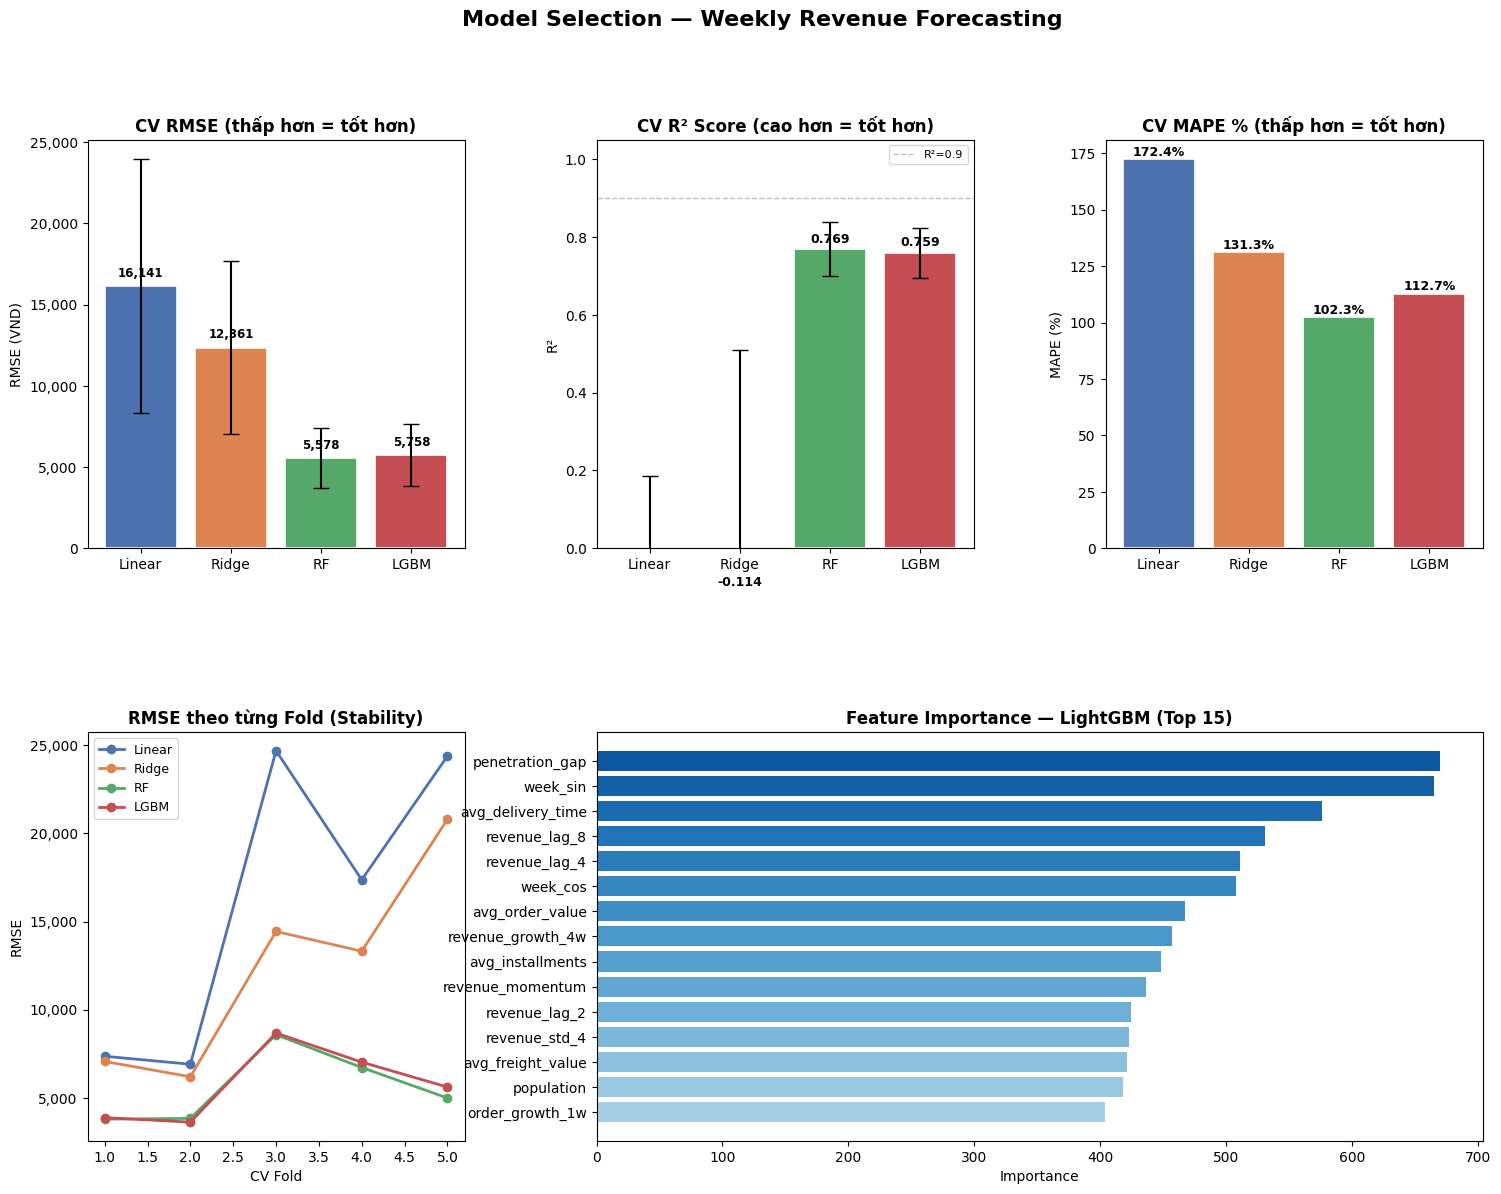

In [18]:
print("\n" + "=" * 70)
print("6. XUẤT BIỂU ĐỒ")
print("=" * 70)

fig = plt.figure(figsize=(18, 13))
fig.suptitle("Model Selection — Weekly Revenue Forecasting", fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
model_names_short = {
    "Linear Regression (Baseline)": "Linear",
    "Ridge Regression":             "Ridge",
    "Random Forest":                "RF",
    "LightGBM":                     "LGBM",
}

# ── 8a. CV RMSE bar + error bar ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
names  = [model_names_short.get(n, n) for n in results]
means  = [np.mean(results[n]['RMSE']) for n in results]
stds   = [np.std(results[n]['RMSE'])  for n in results]
bars = ax1.bar(names, means, yerr=stds, color=colors[:len(names)],
               capsize=6, edgecolor='white', linewidth=1.2)
ax1.set_title("CV RMSE (thấp hơn = tốt hơn)", fontweight='bold')
ax1.set_ylabel("RMSE (VND)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, v in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
             f'{v:,.0f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

# ── 8b. CV R² bar ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r2_means = [np.mean(results[n]['R2']) for n in results]
r2_stds  = [np.std(results[n]['R2'])  for n in results]
bars2 = ax2.bar(names, r2_means, yerr=r2_stds, color=colors[:len(names)],
                capsize=6, edgecolor='white', linewidth=1.2)
ax2.set_title("CV R² Score (cao hơn = tốt hơn)", fontweight='bold')
ax2.set_ylabel("R²")
ax2.set_ylim(0, 1.05)
ax2.axhline(0.9, ls='--', color='gray', lw=1, alpha=0.5, label='R²=0.9')
ax2.legend(fontsize=8)
for bar, v in zip(bars2, r2_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 8c. MAPE bar ─────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
mape_means = [np.nanmean(results[n]['MAPE(%)']) for n in results]
bars3 = ax3.bar(names, mape_means, color=colors[:len(names)], edgecolor='white', linewidth=1.2)
ax3.set_title("CV MAPE % (thấp hơn = tốt hơn)", fontweight='bold')
ax3.set_ylabel("MAPE (%)")
for bar, v in zip(bars3, mape_means):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── 8d. RMSE per fold (line) ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
for i, (name, res) in enumerate(results.items()):
    short = model_names_short.get(name, name)
    ax4.plot(range(1, N_SPLITS+1), res['RMSE'], marker='o', color=colors[i],
             label=short, linewidth=2, markersize=6)
ax4.set_title("RMSE theo từng Fold (Stability)", fontweight='bold')
ax4.set_xlabel("CV Fold")
ax4.set_ylabel("RMSE")
ax4.legend(fontsize=9)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# ── 8e. Feature Importance (best tree model) ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1:])
best_tree = 'LightGBM' if ('LightGBM' in fi_models) else 'Random Forest'
if best_tree in fi_models:
    m    = fi_models[best_tree]
    imp  = pd.Series(m.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True).tail(15)
    cmap = plt.cm.Blues(np.linspace(0.35, 0.85, len(imp)))
    ax5.barh(imp.index, imp.values, color=cmap)
    ax5.set_title(f"Feature Importance — {best_tree} (Top 15)", fontweight='bold')
    ax5.set_xlabel("Importance")

plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
print("   Đã lưu: model_comparison.png")

In [19]:
print("7. KẾT LUẬN & GỢI Ý")

best_name = min(results, key=lambda n: np.mean(results[n]['RMSE']))
best_r2   = max(results, key=lambda n: np.mean(results[n]['R2']))

print(f"""
   Mô hình RMSE tốt nhất : {best_name}
   Mô hình R²   tốt nhất : {best_r2}
""")

plt.show()

7. KẾT LUẬN & GỢI Ý

   Mô hình RMSE tốt nhất : Random Forest
   Mô hình R²   tốt nhất : Random Forest

